# Sanremo & Eurovision Festival Extension

This notebook extends the Music Success Analytics project with a separate analysis of Sanremo Festival and Eurovision Song Contest datasets.

The goal is to explore historical festival results, artist participation, country performance, voting patterns and potential links between national and international music contests.

This extension is kept separate from the main Spotify analytics project to preserve the original project structure.

In [ ]:
import pandas as pd
import numpy as np
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
project_path = "/content/drive/MyDrive/music-success-analytics"

festival_path = project_path + "/festival_extension"
raw_path = festival_path + "/raw"
processed_path = festival_path + "/processed"
quality_reports_path = festival_path + "/quality_reports"

os.makedirs(raw_path, exist_ok=True)
os.makedirs(processed_path, exist_ok=True)
os.makedirs(quality_reports_path, exist_ok=True)

print("Festival path:", festival_path)
print("Raw path:", raw_path)
print("Files in raw folder:")
os.listdir(raw_path)

Festival path: /content/drive/MyDrive/music-success-analytics/festival_extension
Raw path: /content/drive/MyDrive/music-success-analytics/festival_extension/raw
Files in raw folder:


[]

In [ ]:
os.listdir(raw_path)

[]

In [ ]:
from google.colab import drive
drive.flush_and_unmount()

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

base_path = "/content/drive/MyDrive"

os.listdir(base_path)

['FOODWASTEPROJECT.drawio',
 'Colab Notebooks',
 'Untitled spreadsheet.gsheet',
 'music-success-analytics',
 '03_eda_spotify.ipynb']

In [ ]:
project_path = "/content/drive/MyDrive/music-success-analytics"

os.listdir(project_path)

['quality_reports', 'raw', 'processed', 'sql_exports', 'festival_extension']

In [ ]:
festival_path = project_path + "/festival_extension"

os.listdir(festival_path)

['processed', 'quality_reports', 'raw']

In [ ]:
raw_path = festival_path + "/raw"

os.listdir(raw_path)

['Data (eurovision_song_contest_1975_2019v5)_Data (eurovision_song_contest_1.csv',
 'eurovision_2016-25.csv',
 'eurovision_1998 to 2012.xlsx',
 'sanremo_festival.xlsx']

In [ ]:
os.listdir(raw_path)

['Data (eurovision_song_contest_1975_2019v5)_Data (eurovision_song_contest_1.csv',
 'eurovision_2016-25.csv',
 'eurovision_1998 to 2012.xlsx',
 'sanremo_festival.xlsx']

In [ ]:
sanremo_path = raw_path + "/sanremo_festival.xlsx"

sanremo_df = pd.read_excel(sanremo_path)

sanremo_df.head()

,year,placement,artist,artist_id,song,song_id,author
0,1951,1,Nilla Pizzi,a_00001,Grazie dei fiori,s_00001,"Gian Carlo Testoni, Mario Panzeri"
1,1951,2,Nilla Pizzi e Achille Togliani,a_00002,La luna si veste d'argento,s_00002,Biri
2,1951,3,Achille Togliani,a_00003,Serenata a nessuno,s_00003,Walter Col√¨
3,1951,F,Achille Togliani e Duo Fasano,a_00004,Al mercato di Pizzighettone,s_00004,Aldo Locatelli
4,1951,F,Nilla Pizzi e Achille Togliani,a_00002,Eco tra gli abeti,s_00005,Enzo Bonagura


In [ ]:
eurovision_recent_path = raw_path + "/eurovision_2016-25.csv"

eurovision_recent_df = pd.read_csv(
    eurovision_recent_path,
    sep=";",
    encoding="Windows-1252"
)

eurovision_recent_df.head()

,Year,Country,Song,Artist,Final_Place,Final_Points,Top 5,Top 10,Running_Order_Final,Grand_Final_Ind,...,Language4,Multiple_Language,National_Language_Used,EU,NATO,Country_Group,MyESB_Community,MyESB_Personal,OGAE_Points,Qualification_Record
0,2025,Albania,Zjerm,Shkodra Elektronike,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,True,0,1,Southern,4,17,158,0.550000
1,2025,Armenia,Survivor,Parg,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,False,0,0,South-Eastern,30,30,0,0.812500
2,2025,Australia,Milkshake Man,Go-Jo,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,True,0,0,Western,17,21,15,0.777778
3,2025,Austria,Wasted Love,JJ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,False,1,0,Central,1,11,382,0.562500
4,2025,Azerbaijan,Run with U,Mamagama,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,False,0,0,South-Eastern,32,18,0,0.812500


In [ ]:
[file for file in os.listdir(raw_path) if "1975" in file]

['Data (eurovision_song_contest_1975_2019v5)_Data (eurovision_song_contest_1.csv']

In [ ]:
eurovision_voting_file = [file for file in os.listdir(raw_path) if "1975" in file][0]
eurovision_voting_path = raw_path + "/" + eurovision_voting_file

eurovision_voting_df = pd.read_csv(
    eurovision_voting_path,
    sep=";",
    encoding="utf-8-sig"
)

eurovision_voting_df.head()

,(Semi-) Final1,Comments,Duplicate,Edition,From country,Jury or Televoting,To country1,Year1,Points,Index
0,f,NaN,NaN,NaN,Austria,NaN,Luxembourg,01/01/1957,3,1
1,f,NaN,NaN,NaN,Austria,NaN,The Netherlands,01/01/1957,6,2
2,f,NaN,NaN,NaN,Austria,NaN,United Kingdom,01/01/1957,1,3
3,f,NaN,NaN,NaN,Belgium,NaN,France,01/01/1957,2,4
4,f,NaN,NaN,NaN,Belgium,NaN,Germany,01/01/1957,1,5


In [ ]:
[file for file in os.listdir(raw_path) if "1998" in file]

['eurovision_1998 to 2012.xlsx']

In [ ]:
eurovision_1998_2012_file = [file for file in os.listdir(raw_path) if "1998" in file][0]
eurovision_1998_2012_path = raw_path + "/" + eurovision_1998_2012_file

xls = pd.ExcelFile(eurovision_1998_2012_path)

xls.sheet_names

['eurovision_meta', 'Voting Final', 'Performance']

In [ ]:
eurovision_meta_df = pd.read_excel(
    eurovision_1998_2012_path,
    sheet_name="eurovision_meta"
)

eurovision_voting_final_df = pd.read_excel(
    eurovision_1998_2012_path,
    sheet_name="Voting Final"
)

eurovision_performance_df = pd.read_excel(
    eurovision_1998_2012_path,
    sheet_name="Performance"
)

eurovision_meta_df.head()

,Sr.No,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,...,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,...,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,...,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762
3,4,2009,Sweden,Scandinavia,Malena Ernman,La voix,Female,Solo,21,33,...,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692
4,5,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,Both,Group,18,45,...,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,NaN


In [ ]:
eurovision_voting_final_df.head()

,Year,Country,Giver,Score
0,2009,Lithuania,Albania,0
1,2009,Israel,Albania,0
2,2009,France,Albania,2
3,2009,Sweden,Albania,1
4,2009,Croatia,Albania,0


In [ ]:
eurovision_performance_df.head()

,Column name,Type,Description
0,Year,Number,The year of the entry
1,Country,String,Country of the performer
2,Region,String,Region of the performer
3,Artist,String,Name of artist
4,Song,String,Title of song


In [ ]:
dataset_shapes = pd.DataFrame({
    "dataset": [
        "sanremo_df",
        "eurovision_recent_df",
        "eurovision_voting_df",
        "eurovision_meta_df",
        "eurovision_voting_final_df",
        "eurovision_performance_df"
    ],
    "rows": [
        sanremo_df.shape[0],
        eurovision_recent_df.shape[0],
        eurovision_voting_df.shape[0],
        eurovision_meta_df.shape[0],
        eurovision_voting_final_df.shape[0],
        eurovision_performance_df.shape[0]
    ],
    "columns": [
        sanremo_df.shape[1],
        eurovision_recent_df.shape[1],
        eurovision_voting_df.shape[1],
        eurovision_meta_df.shape[1],
        eurovision_voting_final_df.shape[1],
        eurovision_performance_df.shape[1]
    ]
})

dataset_shapes

,dataset,rows,columns
0,sanremo_df,2136,7
1,eurovision_recent_df,358,33
2,eurovision_voting_df,51827,10
3,eurovision_meta_df,648,30
4,eurovision_voting_final_df,12131,4
5,eurovision_performance_df,31,3


In [ ]:
for name, df in {
    "sanremo_df": sanremo_df,
    "eurovision_recent_df": eurovision_recent_df,
    "eurovision_voting_df": eurovision_voting_df,
    "eurovision_meta_df": eurovision_meta_df,
    "eurovision_voting_final_df": eurovision_voting_final_df,
    "eurovision_performance_df": eurovision_performance_df
}.items():
    print("\n" + "="*60)
    print(name)
    print("="*60)
    print(df.columns.tolist())


sanremo_df
['year', 'placement', 'artist', 'artist_id', 'song', 'song_id', 'author']

eurovision_recent_df
['Year', 'Country ', 'Song ', 'Artist ', 'Final_Place', 'Final_Points', 'Top 5', 'Top 10', 'Running_Order_Final', 'Grand_Final_Ind', 'Big6_Ind', 'Semi_Final_Num', 'Semi_Place', 'Semi_Points', 'Running_Order_Semi', 'National_Final', 'Solo_Artist', 'Sex', 'Returning_Artist_Ind', 'Number of Members', 'Language1', 'Language2', 'Language3', 'Language4', 'Multiple_Language', 'National_Language_Used', 'EU', 'NATO', 'Country_Group', 'MyESB_Community', 'MyESB_Personal', 'OGAE_Points', 'Qualification_Record']

eurovision_voting_df
['(Semi-) Final1', 'Comments', 'Duplicate', 'Edition', 'From country', 'Jury or Televoting', 'To country1', 'Year1', 'Points', 'Index']

eurovision_meta_df
['Sr.No', 'Year', 'Country', 'Region', 'Artist', 'Song', 'Artist.gender', 'Group.Solo', 'Place', 'Points', 'Home.Away.Country', 'Home.Away.Region', 'Is.Final', 'Semi.Final.Number', 'Song.In.English', 'Song.Qua

In [ ]:
def missing_report(df, dataset_name):
    return pd.DataFrame({
        "dataset": dataset_name,
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_values": df.isna().sum().values,
        "missing_percentage": (df.isna().mean().values * 100).round(2),
        "unique_values": df.nunique().values
    })

festival_missing_report = pd.concat([
    missing_report(sanremo_df, "sanremo_df"),
    missing_report(eurovision_recent_df, "eurovision_recent_df"),
    missing_report(eurovision_voting_df, "eurovision_voting_df"),
    missing_report(eurovision_meta_df, "eurovision_meta_df"),
    missing_report(eurovision_voting_final_df, "eurovision_voting_final_df"),
    missing_report(eurovision_performance_df, "eurovision_performance_df")
], ignore_index=True)

festival_missing_report

,dataset,column,dtype,missing_values,missing_percentage,unique_values
0,sanremo_df,year,int64,0,0.0,75
1,sanremo_df,placement,object,0,0.0,34
2,sanremo_df,artist,object,0,0.0,982
3,sanremo_df,artist_id,object,0,0.0,978
4,sanremo_df,song,object,0,0.0,1688
...,...,...,...,...,...,...
82,eurovision_voting_final_df,Giver,object,0,0.0,48
83,eurovision_voting_final_df,Score,int64,0,0.0,11
84,eurovision_performance_df,Column name,object,0,0.0,31
85,eurovision_performance_df,Type,object,0,0.0,3


In [ ]:
festival_missing_report.to_csv(
    quality_reports_path + "/festival_missing_values_report.csv",
    index=False
)

In [ ]:
year_coverage = pd.DataFrame({
    "dataset": [
        "sanremo_df",
        "eurovision_recent_df",
        "eurovision_voting_df",
        "eurovision_meta_df",
        "eurovision_voting_final_df"
    ],
    "min_year": [
        sanremo_df["year"].min(),
        eurovision_recent_df["Year"].min(),
        eurovision_voting_df["Year1"].min(),
        eurovision_meta_df["Year"].min(),
        eurovision_voting_final_df["Year"].min()
    ],
    "max_year": [
        sanremo_df["year"].max(),
        eurovision_recent_df["Year"].max(),
        eurovision_voting_df["Year1"].max(),
        eurovision_meta_df["Year"].max(),
        eurovision_voting_final_df["Year"].max()
    ]
})

year_coverage

,dataset,min_year,max_year
0,sanremo_df,1951,2025
1,eurovision_recent_df,2016,2025
2,eurovision_voting_df,01/01/1957,01/01/2025
3,eurovision_meta_df,1998,2012
4,eurovision_voting_final_df,1998,2012


In [ ]:
year_coverage.to_csv(
    quality_reports_path + "/festival_year_coverage.csv",
    index=False
)

In [ ]:
# Fix Eurovision voting year column
eurovision_voting_df["year"] = pd.to_datetime(
    eurovision_voting_df["Year1"],
    errors="coerce",
    dayfirst=True
).dt.year

eurovision_voting_df[["Year1", "year"]].head()

,Year1,year
0,01/01/1957,1957
1,01/01/1957,1957
2,01/01/1957,1957
3,01/01/1957,1957
4,01/01/1957,1957


In [ ]:
year_coverage = pd.DataFrame({
    "dataset": [
        "sanremo_df",
        "eurovision_recent_df",
        "eurovision_voting_df",
        "eurovision_meta_df",
        "eurovision_voting_final_df"
    ],
    "min_year": [
        sanremo_df["year"].min(),
        eurovision_recent_df["Year"].min(),
        eurovision_voting_df["year"].min(),
        eurovision_meta_df["Year"].min(),
        eurovision_voting_final_df["Year"].min()
    ],
    "max_year": [
        sanremo_df["year"].max(),
        eurovision_recent_df["Year"].max(),
        eurovision_voting_df["year"].max(),
        eurovision_meta_df["Year"].max(),
        eurovision_voting_final_df["Year"].max()
    ]
})

year_coverage

,dataset,min_year,max_year
0,sanremo_df,1951,2025
1,eurovision_recent_df,2016,2025
2,eurovision_voting_df,1957,2025
3,eurovision_meta_df,1998,2012
4,eurovision_voting_final_df,1998,2012


In [ ]:
year_coverage.to_csv(
    quality_reports_path + "/festival_year_coverage.csv",
    index=False
)

## Step 2 - Data Cleaning and Feature Engineering

In this section, the festival datasets are cleaned and standardized.  
The goal is to prepare consistent datasets for exploratory analysis and future Tableau visualization.

In [ ]:
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace(".", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
    )
    return df

In [ ]:
sanremo_clean = clean_column_names(sanremo_df)
eurovision_recent_clean = clean_column_names(eurovision_recent_df)
eurovision_voting_clean = clean_column_names(eurovision_voting_df)
eurovision_meta_clean = clean_column_names(eurovision_meta_df)
eurovision_voting_final_clean = clean_column_names(eurovision_voting_final_df)

In [ ]:
for name, df in {
    "sanremo_clean": sanremo_clean,
    "eurovision_recent_clean": eurovision_recent_clean,
    "eurovision_voting_clean": eurovision_voting_clean,
    "eurovision_meta_clean": eurovision_meta_clean,
    "eurovision_voting_final_clean": eurovision_voting_final_clean
}.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)
    print(df.columns.tolist())


sanremo_clean
['year', 'placement', 'artist', 'artist_id', 'song', 'song_id', 'author']

eurovision_recent_clean
['year', 'country', 'song', 'artist', 'final_place', 'final_points', 'top_5', 'top_10', 'running_order_final', 'grand_final_ind', 'big6_ind', 'semi_final_num', 'semi_place', 'semi_points', 'running_order_semi', 'national_final', 'solo_artist', 'sex', 'returning_artist_ind', 'number_of_members', 'language1', 'language2', 'language3', 'language4', 'multiple_language', 'national_language_used', 'eu', 'nato', 'country_group', 'myesb_community', 'myesb_personal', 'ogae_points', 'qualification_record']

eurovision_voting_clean
['semi__final1', 'comments', 'duplicate', 'edition', 'from_country', 'jury_or_televoting', 'to_country1', 'year1', 'points', 'index', 'year']

eurovision_meta_clean
['sr_no', 'year', 'country', 'region', 'artist', 'song', 'artist_gender', 'group_solo', 'place', 'points', 'home_away_country', 'home_away_region', 'is_final', 'semi_final_number', 'song_in_engl

In [ ]:
sanremo_clean["year"] = pd.to_numeric(sanremo_clean["year"], errors="coerce")

sanremo_clean["decade"] = (sanremo_clean["year"] // 10 * 10).astype("Int64")

sanremo_clean["is_winner"] = sanremo_clean["placement"].astype(str).str.strip().eq("1")

sanremo_clean["top_3"] = sanremo_clean["placement"].astype(str).str.strip().isin(["1", "2", "3"])

sanremo_clean.head()

,year,placement,artist,artist_id,song,song_id,author,decade,is_winner,top_3
0,1951,1,Nilla Pizzi,a_00001,Grazie dei fiori,s_00001,"Gian Carlo Testoni, Mario Panzeri",1950,True,True
1,1951,2,Nilla Pizzi e Achille Togliani,a_00002,La luna si veste d'argento,s_00002,Biri,1950,False,True
2,1951,3,Achille Togliani,a_00003,Serenata a nessuno,s_00003,Walter Col√¨,1950,False,True
3,1951,F,Achille Togliani e Duo Fasano,a_00004,Al mercato di Pizzighettone,s_00004,Aldo Locatelli,1950,False,False
4,1951,F,Nilla Pizzi e Achille Togliani,a_00002,Eco tra gli abeti,s_00005,Enzo Bonagura,1950,False,False


In [ ]:
eurovision_recent_clean.columns.tolist()

['year',
 'country',
 'song',
 'artist',
 'final_place',
 'final_points',
 'top_5',
 'top_10',
 'running_order_final',
 'grand_final_ind',
 'big6_ind',
 'semi_final_num',
 'semi_place',
 'semi_points',
 'running_order_semi',
 'national_final',
 'solo_artist',
 'sex',
 'returning_artist_ind',
 'number_of_members',
 'language1',
 'language2',
 'language3',
 'language4',
 'multiple_language',
 'national_language_used',
 'eu',
 'nato',
 'country_group',
 'myesb_community',
 'myesb_personal',
 'ogae_points',
 'qualification_record']

In [ ]:
eurovision_recent_clean["year"] = pd.to_numeric(eurovision_recent_clean["year"], errors="coerce")

eurovision_recent_clean["decade"] = (eurovision_recent_clean["year"] // 10 * 10).astype("Int64")

eurovision_recent_clean["final_place"] = pd.to_numeric(
    eurovision_recent_clean["final_place"],
    errors="coerce"
)

eurovision_recent_clean["final_points"] = pd.to_numeric(
    eurovision_recent_clean["final_points"],
    errors="coerce"
)

eurovision_recent_clean["is_winner"] = eurovision_recent_clean["final_place"].eq(1)

eurovision_recent_clean["top_3"] = eurovision_recent_clean["final_place"].between(1, 3)

eurovision_recent_clean["top_10_flag"] = eurovision_recent_clean["final_place"].between(1, 10)

eurovision_recent_clean.head()

,year,country,song,artist,final_place,final_points,top_5,top_10,running_order_final,grand_final_ind,...,nato,country_group,myesb_community,myesb_personal,ogae_points,qualification_record,decade,is_winner,top_3,top_10_flag
0,2025,Albania,Zjerm,Shkodra Elektronike,NaN,NaN,NaN,NaN,NaN,NaN,...,1,Southern,4,17,158,0.550000,2020,False,False,False
1,2025,Armenia,Survivor,Parg,NaN,NaN,NaN,NaN,NaN,NaN,...,0,South-Eastern,30,30,0,0.812500,2020,False,False,False
2,2025,Australia,Milkshake Man,Go-Jo,NaN,NaN,NaN,NaN,NaN,NaN,...,0,Western,17,21,15,0.777778,2020,False,False,False
3,2025,Austria,Wasted Love,JJ,NaN,NaN,NaN,NaN,NaN,NaN,...,0,Central,1,11,382,0.562500,2020,False,False,False
4,2025,Azerbaijan,Run with U,Mamagama,NaN,NaN,NaN,NaN,NaN,NaN,...,0,South-Eastern,32,18,0,0.812500,2020,False,False,False


In [ ]:
eurovision_meta_clean["year"] = pd.to_numeric(eurovision_meta_clean["year"], errors="coerce")

eurovision_meta_clean["decade"] = (eurovision_meta_clean["year"] // 10 * 10).astype("Int64")

eurovision_meta_clean["place"] = pd.to_numeric(
    eurovision_meta_clean["place"],
    errors="coerce"
)

eurovision_meta_clean["points"] = pd.to_numeric(
    eurovision_meta_clean["points"],
    errors="coerce"
)

eurovision_meta_clean["is_winner"] = eurovision_meta_clean["place"].eq(1)

eurovision_meta_clean["top_3"] = eurovision_meta_clean["place"].between(1, 3)

eurovision_meta_clean["top_10"] = eurovision_meta_clean["place"].between(1, 10)

eurovision_meta_clean.head()

,sr_no,year,country,region,artist,song,artist_gender,group_solo,place,points,...,liveness,time_signature,mode,loudness,valence,happiness,decade,is_winner,top_3,top_10
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,...,0.078643,3.0,0.0,-9.082,0.482059,6.148232,2000,False,False,False
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,...,0.084805,4.0,1.0,-6.059,0.426209,5.141887,2000,False,False,False
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,...,0.923905,4.0,1.0,-8.655,0.292870,5.069762,2000,False,False,True
3,4,2009,Sweden,Scandinavia,Malena Ernman,La voix,Female,Solo,21,33,...,0.143708,4.0,1.0,-4.536,0.206493,5.502692,2000,False,False,False
4,5,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,Both,Group,18,45,...,0.079322,4.0,0.0,-4.427,0.344541,NaN,2000,False,False,False


In [ ]:
if "year" not in eurovision_voting_clean.columns:
    eurovision_voting_clean["year"] = pd.to_datetime(
        eurovision_voting_clean["year1"],
        errors="coerce",
        dayfirst=True
    ).dt.year

eurovision_voting_clean["points"] = pd.to_numeric(
    eurovision_voting_clean["points"],
    errors="coerce"
)

eurovision_voting_clean.head()

,semi__final1,comments,duplicate,edition,from_country,jury_or_televoting,to_country1,year1,points,index,year
0,f,NaN,NaN,NaN,Austria,NaN,Luxembourg,01/01/1957,3,1,1957
1,f,NaN,NaN,NaN,Austria,NaN,The Netherlands,01/01/1957,6,2,1957
2,f,NaN,NaN,NaN,Austria,NaN,United Kingdom,01/01/1957,1,3,1957
3,f,NaN,NaN,NaN,Belgium,NaN,France,01/01/1957,2,4,1957
4,f,NaN,NaN,NaN,Belgium,NaN,Germany,01/01/1957,1,5,1957


In [ ]:
sanremo_clean.to_csv(processed_path + "/sanremo_clean.csv", index=False)
eurovision_recent_clean.to_csv(processed_path + "/eurovision_recent_clean.csv", index=False)
eurovision_voting_clean.to_csv(processed_path + "/eurovision_voting_clean.csv", index=False)
eurovision_meta_clean.to_csv(processed_path + "/eurovision_meta_clean.csv", index=False)
eurovision_voting_final_clean.to_csv(processed_path + "/eurovision_voting_final_clean.csv", index=False)

os.listdir(processed_path)

['sanremo_clean.csv',
 'eurovision_recent_clean.csv',
 'eurovision_voting_clean.csv',
 'eurovision_meta_clean.csv',
 'eurovision_voting_final_clean.csv']

In [ ]:
eurovision_voting_clean = eurovision_voting_clean.rename(columns={
    "semi__final1": "stage",
    "to_country1": "to_country",
    "year1": "original_year"
})

In [ ]:
eurovision_voting_clean.head()

,stage,comments,duplicate,edition,from_country,jury_or_televoting,to_country,original_year,points,index,year
0,f,NaN,NaN,NaN,Austria,NaN,Luxembourg,01/01/1957,3,1,1957
1,f,NaN,NaN,NaN,Austria,NaN,The Netherlands,01/01/1957,6,2,1957
2,f,NaN,NaN,NaN,Austria,NaN,United Kingdom,01/01/1957,1,3,1957
3,f,NaN,NaN,NaN,Belgium,NaN,France,01/01/1957,2,4,1957
4,f,NaN,NaN,NaN,Belgium,NaN,Germany,01/01/1957,1,5,1957


In [ ]:
eurovision_voting_clean.columns.tolist()

['stage',
 'comments',
 'duplicate',
 'edition',
 'from_country',
 'jury_or_televoting',
 'to_country',
 'original_year',
 'points',
 'index',
 'year']

In [ ]:
eurovision_voting_clean.to_csv(
    processed_path + "/eurovision_voting_clean.csv",
    index=False
)

In [ ]:
pd.read_csv(processed_path + "/eurovision_voting_clean.csv").head()

,stage,comments,duplicate,edition,from_country,jury_or_televoting,to_country,original_year,points,index,year
0,f,NaN,NaN,NaN,Austria,NaN,Luxembourg,01/01/1957,3,1,1957
1,f,NaN,NaN,NaN,Austria,NaN,The Netherlands,01/01/1957,6,2,1957
2,f,NaN,NaN,NaN,Austria,NaN,United Kingdom,01/01/1957,1,3,1957
3,f,NaN,NaN,NaN,Belgium,NaN,France,01/01/1957,2,4,1957
4,f,NaN,NaN,NaN,Belgium,NaN,Germany,01/01/1957,1,5,1957


## Step 3 - Exploratory Data Analysis

In this section, we explore Sanremo and Eurovision datasets separately to identify historical trends, recurring artists, country performance and contest-related patterns.

In [ ]:
sanremo_overview = pd.DataFrame({
    "metric": [
        "total_entries",
        "unique_years",
        "min_year",
        "max_year",
        "unique_artists",
        "unique_songs",
        "unique_authors"
    ],
    "value": [
        len(sanremo_clean),
        sanremo_clean["year"].nunique(),
        sanremo_clean["year"].min(),
        sanremo_clean["year"].max(),
        sanremo_clean["artist"].nunique(),
        sanremo_clean["song"].nunique(),
        sanremo_clean["author"].nunique()
    ]
})

sanremo_overview

,metric,value
0,total_entries,2136
1,unique_years,75
2,min_year,1951
3,max_year,2025
4,unique_artists,982
5,unique_songs,1688
6,unique_authors,1461


In [ ]:
sanremo_entries_by_decade = (
    sanremo_clean
    .groupby("decade")
    .size()
    .reset_index(name="entries")
    .sort_values("decade")
)

sanremo_entries_by_decade

,decade,entries
0,1950,290
1,1960,496
2,1970,294
3,1980,262
4,1990,214
5,2000,212
6,2010,205
7,2020,163


### Sanremo Entries by Decade

The number of Sanremo entries varies significantly across decades.  
The 1960s show the highest number of entries, with 496 songs included in the dataset.

After the 1960s, the number of entries gradually decreases across later decades.  
The 2020s should be interpreted carefully because this decade is still incomplete and only covers the years available up to 2025.

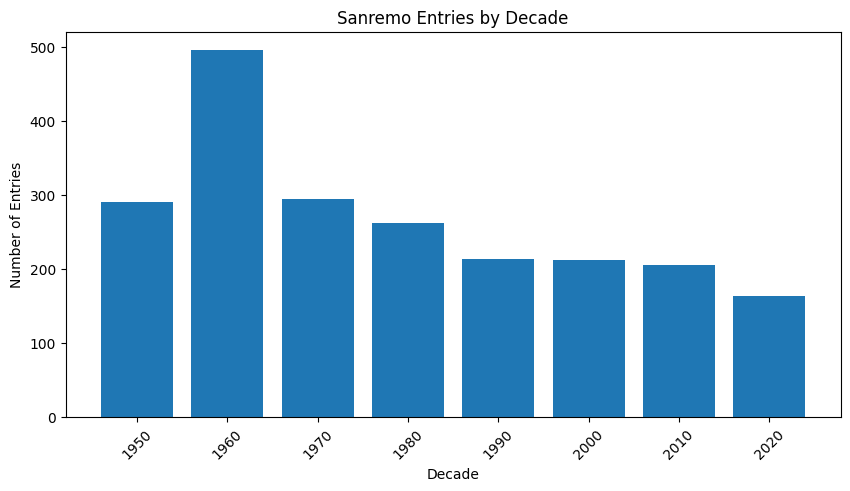

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(
    sanremo_entries_by_decade["decade"].astype(str),
    sanremo_entries_by_decade["entries"]
)

plt.title("Sanremo Entries by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Entries")
plt.xticks(rotation=45)
plt.show()

### Sanremo Dataset Overview

The Sanremo dataset contains 2,136 entries across 75 editions, covering the period from 1951 to 2025.  
It includes 982 unique artists, 1,688 unique songs and 1,461 unique authors.

This makes the dataset suitable for analyzing long-term participation trends, recurring artists, winning songs and historical changes across decades.

In [ ]:
top_sanremo_artists = (
    sanremo_clean
    .groupby("artist")
    .agg(
        participations=("song", "count"),
        first_year=("year", "min"),
        last_year=("year", "max"),
        wins=("is_winner", "sum"),
        top_3_finishes=("top_3", "sum")
    )
    .reset_index()
    .sort_values(["participations", "wins", "top_3_finishes"], ascending=False)
    .head(20)
)

top_sanremo_artists

,artist,participations,first_year,last_year,wins,top_3_finishes
4,Achille Togliani,23,1951,1961,0,4
160,Claudio Villa,21,1955,1982,4,7
684,Nilla Pizzi,20,1951,1960,2,6
380,Gino Latilla,20,1952,1961,1,6
636,Milva,17,1961,2007,0,6
927,Tonina Torrielli,17,1956,1963,0,3
390,Giorgio Consolini,16,1953,1962,1,3
461,Johnny Dorelli,15,1958,2007,2,2
62,Anna Oxa,14,1978,2023,1,3
294,Flo Sandon's,13,1953,1963,1,1


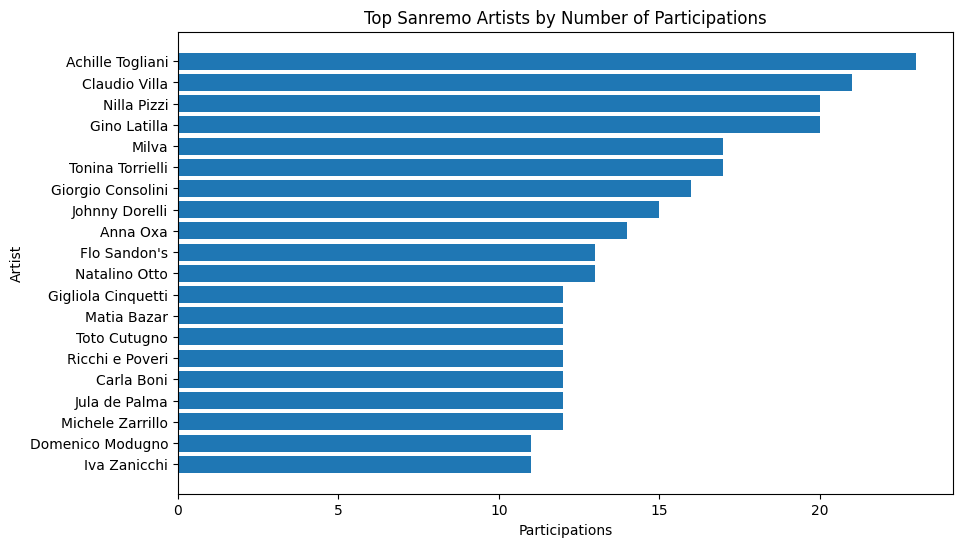

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_sanremo_artists["artist"].iloc[::-1],
    top_sanremo_artists["participations"].iloc[::-1]
)

plt.title("Top Sanremo Artists by Number of Participations")
plt.xlabel("Participations")
plt.ylabel("Artist")
plt.show()

### Top Sanremo Artists by Number of Participations

The analysis shows that some artists appeared repeatedly across Sanremo history.  
Achille Togliani, Claudio Villa, Nilla Pizzi and Gino Latilla are among the most frequent participants in the dataset.

This suggests that Sanremo has historically relied on recurring artists, especially in earlier decades.  
Some artists also show long-term presence across different periods, such as Anna Oxa and Toto Cutugno.

In [ ]:
sanremo_winners_by_artist = (
    sanremo_clean[sanremo_clean["is_winner"] == True]
    .groupby("artist")
    .agg(
        wins=("is_winner", "sum"),
        first_win_year=("year", "min"),
        last_win_year=("year", "max"),
        winning_songs=("song", lambda x: ", ".join(x.astype(str).unique()[:5]))
    )
    .reset_index()
    .sort_values(["wins", "first_win_year"], ascending=[False, True])
)

sanremo_winners_by_artist.head(20)

,artist,wins,first_win_year,last_win_year,winning_songs
14,Claudio Villa,4,1955,1967,"Buongiorno tristezza, Corde della mia chitarra..."
16,Domenico Modugno,4,1958,1966,"Nel blu dipinto di blu, Piove (ciao ciao bambi..."
36,Iva Zanicchi,3,1967,1974,"Non pensare a me, Zingara, Ciao cara come stai?"
52,Nilla Pizzi,2,1951,1952,"Grazie dei fiori, Vola colomba"
38,Johnny Dorelli,2,1958,1959,"Nel blu dipinto di blu, Piove (ciao ciao bambina)"
28,Gigliola Cinquetti,2,1964,1966,"Non ho l'et√† (Per amarti), Dio, come ti amo"
11,Bobby Solo,2,1965,1969,"Se piangi, se ridi, Zingara"
51,Nicola Di Bari,2,1971,1972,"Il cuore √® uno zingaro, I giorni dell'arcobaleno"
56,Peppino Di Capri,2,1973,1976,"Un grande amore e niente pi√π, Non lo faccio pi√π"
47,Matia Bazar,2,1978,2002,"...e dirsi ciao, Messaggio d'amore"


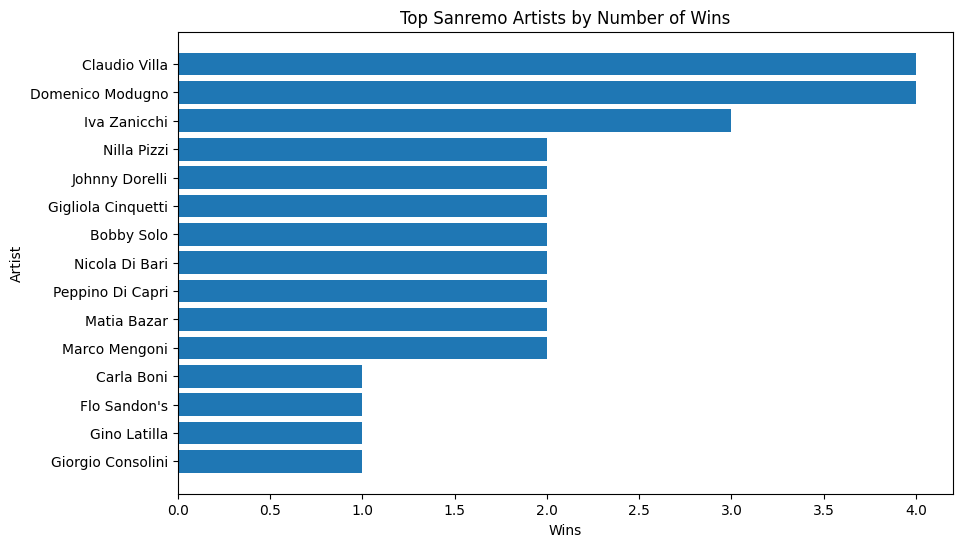

In [ ]:
top_sanremo_winners = sanremo_winners_by_artist.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_sanremo_winners["artist"].iloc[::-1],
    top_sanremo_winners["wins"].iloc[::-1]
)

plt.title("Top Sanremo Artists by Number of Wins")
plt.xlabel("Wins")
plt.ylabel("Artist")
plt.show()

### Top Sanremo Artists by Number of Wins

The winners analysis shows that Claudio Villa and Domenico Modugno are the top Sanremo winners in the dataset, with four victories each.

Other historically successful artists include Iva Zanicchi, Nilla Pizzi, Johnny Dorelli, Gigliola Cinquetti, Bobby Solo, Nicola Di Bari, Peppino Di Capri and Matia Bazar.

This analysis highlights the difference between frequent participation and actual winning performance: some artists appeared many times, while others had fewer entries but stronger winning records.

In [ ]:
top_sanremo_authors = (
    sanremo_clean
    .groupby("author")
    .agg(
        songs_written=("song", "count"),
        first_year=("year", "min"),
        last_year=("year", "max"),
        wins=("is_winner", "sum"),
        top_3_finishes=("top_3", "sum")
    )
    .reset_index()
    .sort_values(["songs_written", "wins", "top_3_finishes"], ascending=False)
    .head(20)
)

top_sanremo_authors

,author,songs_written,first_year,last_year,wins,top_3_finishes
680,"G. Morra, M. Fabrizio",13,1982,2009,0,2
766,"L. Albertelli, E. Riccardi",10,1969,1976,2,2
773,L. Barbarossa,9,1981,2018,1,2
626,G. D'Anzi,8,1953,1961,2,4
170,"B. Pallesi, W. Malgoni",8,1959,1964,0,4
1005,"Mogol, C. Donida",8,1965,1971,0,2
689,G. Paoli,7,1961,2002,0,3
1432,"V. Pallavicini, P. Donaggio",7,1965,1972,0,2
538,F. Silvestre,7,2005,2025,0,1
946,"M. Panzeri, V. Mascheroni",7,1956,1960,0,1


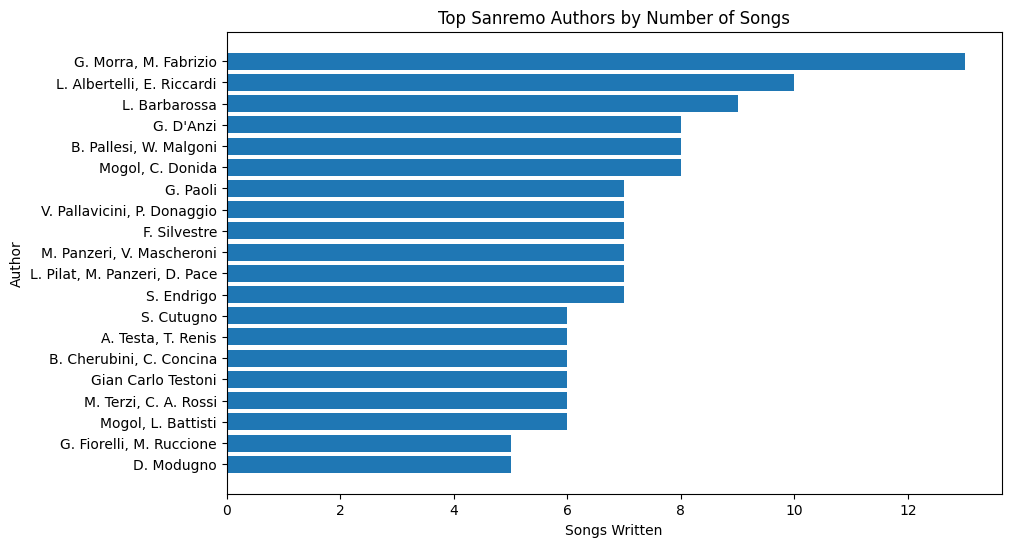

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_sanremo_authors["author"].iloc[::-1],
    top_sanremo_authors["songs_written"].iloc[::-1]
)

plt.title("Top Sanremo Authors by Number of Songs")
plt.xlabel("Songs Written")
plt.ylabel("Author")
plt.show()

### Top Sanremo Authors by Number of Songs

The authors analysis shows the most frequent songwriting credits in the Sanremo dataset.

Some entries include multiple authors in the same field, so this analysis currently counts author combinations rather than individual songwriters.

Even with this limitation, the result highlights recurring songwriting teams and composers across Sanremo history.

In [ ]:
sanremo_overview.to_csv(
    processed_path + "/sanremo_overview.csv",
    index=False
)

sanremo_entries_by_decade.to_csv(
    processed_path + "/sanremo_entries_by_decade.csv",
    index=False
)

top_sanremo_artists.to_csv(
    processed_path + "/top_sanremo_artists.csv",
    index=False
)

sanremo_winners_by_artist.to_csv(
    processed_path + "/sanremo_winners_by_artist.csv",
    index=False
)

top_sanremo_authors.to_csv(
    processed_path + "/top_sanremo_authors.csv",
    index=False
)

os.listdir(processed_path)

['sanremo_clean.csv',
 'eurovision_recent_clean.csv',
 'eurovision_voting_clean.csv',
 'eurovision_meta_clean.csv',
 'eurovision_voting_final_clean.csv',
 'sanremo_overview.csv',
 'sanremo_entries_by_decade.csv',
 'top_sanremo_artists.csv',
 'sanremo_winners_by_artist.csv',
 'top_sanremo_authors.csv']

In [ ]:
sanremo_authors_exploded = sanremo_clean.copy()

sanremo_authors_exploded["author_single"] = (
    sanremo_authors_exploded["author"]
    .astype(str)
    .str.split(",")
)

sanremo_authors_exploded = sanremo_authors_exploded.explode("author_single")

sanremo_authors_exploded["author_single"] = (
    sanremo_authors_exploded["author_single"]
    .astype(str)
    .str.strip()
)

sanremo_authors_exploded = sanremo_authors_exploded[
    sanremo_authors_exploded["author_single"].notna()
]

sanremo_authors_exploded = sanremo_authors_exploded[
    sanremo_authors_exploded["author_single"] != ""
]

sanremo_authors_exploded.head()

,year,placement,artist,artist_id,song,song_id,author,decade,is_winner,top_3,author_single
0,1951,1,Nilla Pizzi,a_00001,Grazie dei fiori,s_00001,"Gian Carlo Testoni, Mario Panzeri",1950,True,True,Gian Carlo Testoni
0,1951,1,Nilla Pizzi,a_00001,Grazie dei fiori,s_00001,"Gian Carlo Testoni, Mario Panzeri",1950,True,True,Mario Panzeri
1,1951,2,Nilla Pizzi e Achille Togliani,a_00002,La luna si veste d'argento,s_00002,Biri,1950,False,True,Biri
2,1951,3,Achille Togliani,a_00003,Serenata a nessuno,s_00003,Walter Col√¨,1950,False,True,Walter Col√¨
3,1951,F,Achille Togliani e Duo Fasano,a_00004,Al mercato di Pizzighettone,s_00004,Aldo Locatelli,1950,False,False,Aldo Locatelli


In [ ]:
print("Original Sanremo rows:", sanremo_clean.shape[0])
print("Exploded author rows:", sanremo_authors_exploded.shape[0])
print("Unique original author fields:", sanremo_clean["author"].nunique())
print("Unique individual authors:", sanremo_authors_exploded["author_single"].nunique())

Original Sanremo rows: 2136
Exploded author rows: 4930
Unique original author fields: 1461
Unique individual authors: 1805


In [ ]:
top_sanremo_individual_authors = (
    sanremo_authors_exploded
    .groupby("author_single")
    .agg(
        songs_written=("song", "count"),
        first_year=("year", "min"),
        last_year=("year", "max"),
        wins=("is_winner", "sum"),
        top_3_finishes=("top_3", "sum")
    )
    .reset_index()
    .sort_values(["songs_written", "wins", "top_3_finishes"], ascending=False)
    .head(20)
)

top_sanremo_individual_authors

,author_single,songs_written,first_year,last_year,wins,top_3_finishes
1760,V. Pallavicini,82,1961,1989,0,22
1270,Mogol,73,1962,2009,5,17
155,A. Testa,56,1956,1975,4,10
1187,M. Panzeri,56,1954,1982,2,8
394,D. Pace,55,1961,1985,0,6
712,G. Bigazzi,34,1969,2003,2,4
627,F. Migliacci,33,1960,1997,4,9
952,L. Albertelli,32,1969,1986,2,3
1132,M. Fabrizio,28,1971,2017,2,5
963,L. Beretta,27,1956,1976,2,5


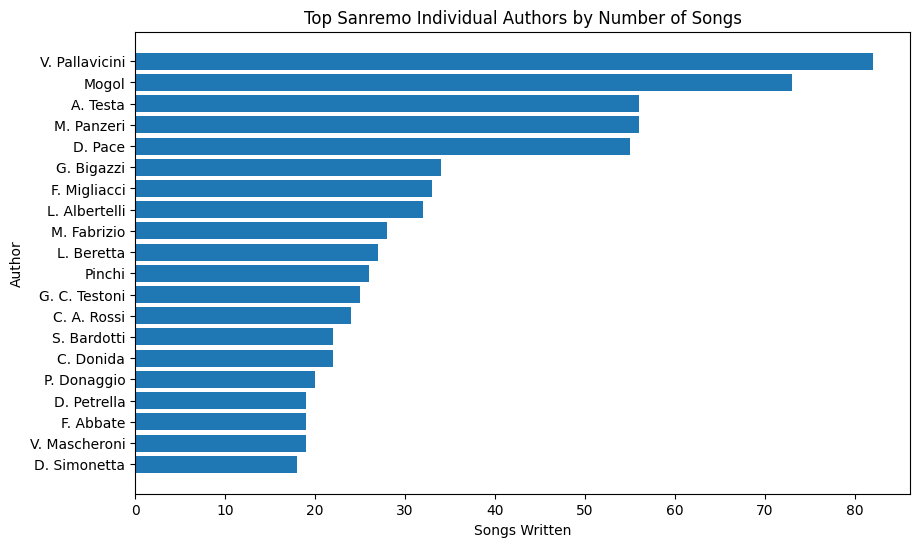

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_sanremo_individual_authors["author_single"].iloc[::-1],
    top_sanremo_individual_authors["songs_written"].iloc[::-1]
)

plt.title("Top Sanremo Individual Authors by Number of Songs")
plt.xlabel("Songs Written")
plt.ylabel("Author")
plt.show()

### Top Sanremo Individual Authors by Number of Songs

The original author field often contains multiple songwriters in the same cell.  
To obtain a more accurate author-level analysis, the author column was split and exploded so that each songwriter is counted individually.

This allows the analysis to identify the most recurrent individual authors across Sanremo history, rather than counting author teams as single entities.

In [ ]:
sanremo_authors_exploded.to_csv(
    processed_path + "/sanremo_authors_exploded.csv",
    index=False
)

top_sanremo_individual_authors.to_csv(
    processed_path + "/top_sanremo_individual_authors.csv",
    index=False
)

In [ ]:
sanremo_overview.to_csv(
    processed_path + "/sanremo_overview.csv",
    index=False
)

sanremo_entries_by_decade.to_csv(
    processed_path + "/sanremo_entries_by_decade.csv",
    index=False
)

top_sanremo_artists.to_csv(
    processed_path + "/top_sanremo_artists.csv",
    index=False
)

sanremo_winners_by_artist.to_csv(
    processed_path + "/sanremo_winners_by_artist.csv",
    index=False
)

top_sanremo_individual_authors.to_csv(
    processed_path + "/top_sanremo_individual_authors.csv",
    index=False
)

os.listdir(processed_path)

['sanremo_clean.csv',
 'eurovision_recent_clean.csv',
 'eurovision_voting_clean.csv',
 'eurovision_meta_clean.csv',
 'eurovision_voting_final_clean.csv',
 'sanremo_overview.csv',
 'sanremo_entries_by_decade.csv',
 'top_sanremo_artists.csv',
 'sanremo_winners_by_artist.csv',
 'top_sanremo_authors.csv',
 'sanremo_authors_exploded.csv',
 'top_sanremo_individual_authors.csv']

### Eurovision Recent Dataset Overview

This section explores the Eurovision recent dataset, covering editions from 2016 to 2025.  
The goal is to analyze country performance, final placements, points, Top 5 and Top 10 results.

In [ ]:
eurovision_recent_overview = pd.DataFrame({
    "metric": [
        "total_entries",
        "unique_years",
        "min_year",
        "max_year",
        "unique_countries",
        "unique_artists",
        "unique_songs"
    ],
    "value": [
        len(eurovision_recent_clean),
        eurovision_recent_clean["year"].nunique(),
        eurovision_recent_clean["year"].min(),
        eurovision_recent_clean["year"].max(),
        eurovision_recent_clean["country"].nunique(),
        eurovision_recent_clean["artist"].nunique(),
        eurovision_recent_clean["song"].nunique()
    ]
})

eurovision_recent_overview

,metric,value
0,total_entries,358
1,unique_years,9
2,min_year,2016
3,max_year,2025
4,unique_countries,46
5,unique_artists,354
6,unique_songs,355


In [ ]:
eurovision_country_performance = (
    eurovision_recent_clean
    .groupby("country")
    .agg(
        entries=("song", "count"),
        avg_final_place=("final_place", "mean"),
        best_final_place=("final_place", "min"),
        total_final_points=("final_points", "sum"),
        avg_final_points=("final_points", "mean"),
        wins=("is_winner", "sum"),
        top_3_finishes=("top_3", "sum"),
        top_10_finishes=("top_10_flag", "sum")
    )
    .reset_index()
)

eurovision_country_performance["avg_final_place"] = eurovision_country_performance["avg_final_place"].round(2)
eurovision_country_performance["avg_final_points"] = eurovision_country_performance["avg_final_points"].round(2)

eurovision_country_performance = eurovision_country_performance.sort_values(
    ["wins", "top_3_finishes", "top_10_finishes", "total_final_points"],
    ascending=False
)

eurovision_country_performance.head(20)

,country,entries,avg_final_place,best_final_place,total_final_points,avg_final_points,wins,top_3_finishes,top_10_finishes
44,Ukraine,8,8.14,1.0,2391.0,341.57,2,3,5
24,Italy,9,5.88,1.0,2648.0,331.00,1,2,7
23,Israel,9,12.29,1.0,1568.0,224.00,1,2,3
43,Switzerland,9,9.00,1.0,1557.0,311.40,1,2,3
42,Sweden,9,6.25,1.0,2517.0,314.62,1,1,7
35,Portugal,8,13.50,1.0,1368.0,228.00,1,1,3
31,Netherlands,9,12.50,1.0,1104.0,184.00,1,1,1
37,Russia,4,5.00,3.0,1065.0,355.00,0,2,3
2,Australia,9,10.67,2.0,1343.0,223.83,0,1,4
16,France,9,11.62,2.0,1735.0,216.88,0,1,3


In [ ]:
eurovision_recent_overview.to_csv(
    processed_path + "/eurovision_recent_overview.csv",
    index=False
)

eurovision_country_performance.to_csv(
    processed_path + "/eurovision_country_performance.csv",
    index=False
)

top_eurovision_countries_points.to_csv(
    processed_path + "/top_eurovision_countries_points.csv",
    index=False
)

top_eurovision_countries_top10.to_csv(
    processed_path + "/top_eurovision_countries_top10.csv",
    index=False
)

os.listdir(processed_path)

['sanremo_clean.csv',
 'eurovision_recent_clean.csv',
 'eurovision_voting_clean.csv',
 'eurovision_meta_clean.csv',
 'eurovision_voting_final_clean.csv',
 'sanremo_overview.csv',
 'sanremo_entries_by_decade.csv',
 'top_sanremo_artists.csv',
 'sanremo_winners_by_artist.csv',
 'top_sanremo_authors.csv',
 'sanremo_authors_exploded.csv',
 'top_sanremo_individual_authors.csv',
 'eurovision_recent_overview.csv',
 'eurovision_country_performance.csv',
 'top_eurovision_countries_points.csv',
 'top_eurovision_countries_top10.csv']

In [ ]:
eurovision_recent_overview

,metric,value
0,total_entries,358
1,unique_years,9
2,min_year,2016
3,max_year,2025
4,unique_countries,46
5,unique_artists,354
6,unique_songs,355


In [ ]:
eurovision_country_performance.head(20)

,country,entries,avg_final_place,best_final_place,total_final_points,avg_final_points,wins,top_3_finishes,top_10_finishes
44,Ukraine,8,8.14,1.0,2391.0,341.57,2,3,5
24,Italy,9,5.88,1.0,2648.0,331.00,1,2,7
23,Israel,9,12.29,1.0,1568.0,224.00,1,2,3
43,Switzerland,9,9.00,1.0,1557.0,311.40,1,2,3
42,Sweden,9,6.25,1.0,2517.0,314.62,1,1,7
35,Portugal,8,13.50,1.0,1368.0,228.00,1,1,3
31,Netherlands,9,12.50,1.0,1104.0,184.00,1,1,1
37,Russia,4,5.00,3.0,1065.0,355.00,0,2,3
2,Australia,9,10.67,2.0,1343.0,223.83,0,1,4
16,France,9,11.62,2.0,1735.0,216.88,0,1,3


### Eurovision Recent Dataset Overview

The recent Eurovision dataset contains 358 entries from 2016 to 2025, covering 46 countries, 354 artists and 355 songs.

Although the year range goes from 2016 to 2025, the dataset includes 9 unique years, likely because the 2020 contest was cancelled.

The country performance table shows that Ukraine, Italy, Sweden, Switzerland and Israel are among the strongest performers in the recent period, based on wins, Top 3 finishes, Top 10 finishes and total final points.

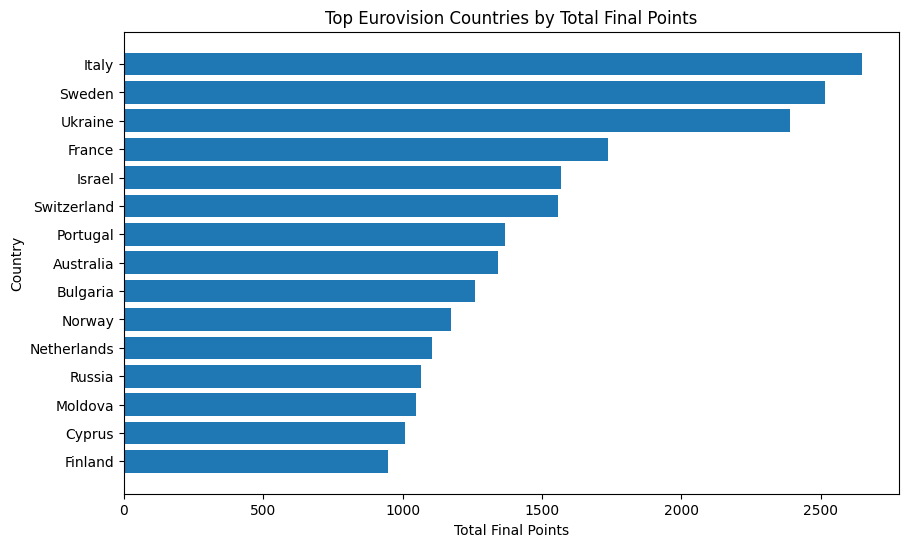

In [ ]:
top_eurovision_countries_points = (
    eurovision_country_performance
    .sort_values("total_final_points", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_eurovision_countries_points["country"].iloc[::-1],
    top_eurovision_countries_points["total_final_points"].iloc[::-1]
)

plt.title("Top Eurovision Countries by Total Final Points")
plt.xlabel("Total Final Points")
plt.ylabel("Country")
plt.show()

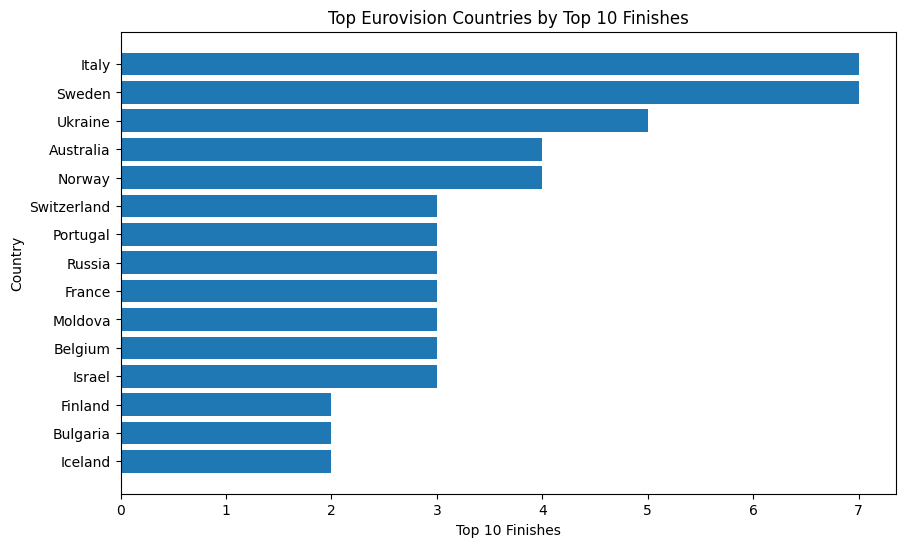

In [ ]:
top_eurovision_countries_top10 = (
    eurovision_country_performance
    .sort_values("top_10_finishes", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_eurovision_countries_top10["country"].iloc[::-1],
    top_eurovision_countries_top10["top_10_finishes"].iloc[::-1]
)

plt.title("Top Eurovision Countries by Top 10 Finishes")
plt.xlabel("Top 10 Finishes")
plt.ylabel("Country")
plt.show()

In [ ]:
eurovision_recent_overview.to_csv(
    processed_path + "/eurovision_recent_overview.csv",
    index=False
)

eurovision_country_performance.to_csv(
    processed_path + "/eurovision_country_performance.csv",
    index=False
)

top_eurovision_countries_points.to_csv(
    processed_path + "/top_eurovision_countries_points.csv",
    index=False
)

top_eurovision_countries_top10.to_csv(
    processed_path + "/top_eurovision_countries_top10.csv",
    index=False
)

os.listdir(processed_path)

['sanremo_clean.csv',
 'eurovision_recent_clean.csv',
 'eurovision_voting_clean.csv',
 'eurovision_meta_clean.csv',
 'eurovision_voting_final_clean.csv',
 'sanremo_overview.csv',
 'sanremo_entries_by_decade.csv',
 'top_sanremo_artists.csv',
 'sanremo_winners_by_artist.csv',
 'top_sanremo_authors.csv',
 'sanremo_authors_exploded.csv',
 'top_sanremo_individual_authors.csv',
 'eurovision_recent_overview.csv',
 'eurovision_country_performance.csv',
 'top_eurovision_countries_points.csv',
 'top_eurovision_countries_top10.csv']

### Eurovision Audio Features Analysis

This section explores the Eurovision 1998–2012 metadata dataset, which includes audio-related variables such as energy, danceability, acousticness, tempo, loudness and valence.

The goal is to compare audio characteristics between winning songs, Top 10 songs and the rest of the competition.

In [ ]:
eurovision_meta_clean.columns.tolist()

['sr_no',
 'year',
 'country',
 'region',
 'artist',
 'song',
 'artist_gender',
 'group_solo',
 'place',
 'points',
 'home_away_country',
 'home_away_region',
 'is_final',
 'semi_final_number',
 'song_in_english',
 'song_quality',
 'normalized_points',
 'energy',
 'duration',
 'acousticness',
 'danceability',
 'tempo',
 'speechiness',
 'key',
 'liveness',
 'time_signature',
 'mode',
 'loudness',
 'valence',
 'happiness',
 'decade',
 'is_winner',
 'top_3',
 'top_10']

In [ ]:
eurovision_audio_overview = pd.DataFrame({
    "metric": [
        "total_entries",
        "unique_years",
        "min_year",
        "max_year",
        "unique_countries",
        "unique_artists",
        "unique_songs",
        "winners",
        "top_10_songs"
    ],
    "value": [
        len(eurovision_meta_clean),
        eurovision_meta_clean["year"].nunique(),
        eurovision_meta_clean["year"].min(),
        eurovision_meta_clean["year"].max(),
        eurovision_meta_clean["country"].nunique(),
        eurovision_meta_clean["artist"].nunique(),
        eurovision_meta_clean["song"].nunique(),
        eurovision_meta_clean["is_winner"].sum(),
        eurovision_meta_clean["top_10"].sum()
    ]
})

eurovision_audio_overview

,metric,value
0,total_entries,648
1,unique_years,15
2,min_year,1998
3,max_year,2012
4,unique_countries,48
5,unique_artists,530
6,unique_songs,509
7,winners,29
8,top_10_songs,290


In [ ]:
audio_features = [
    "energy",
    "danceability",
    "acousticness",
    "tempo",
    "loudness",
    "valence"
]

eurovision_meta_clean[audio_features].describe()

,energy,danceability,acousticness,tempo,loudness,valence
count,482.000000,482.000000,480.000000,482.000000,482.000000,480.000000
mean,0.725833,0.571246,0.164345,113.905349,-6.516718,0.521286
std,0.186675,0.136131,0.226211,24.958535,2.358372,0.236548
min,0.064730,0.183719,0.000413,64.971000,-21.878000,0.017786
25%,0.607444,0.489436,0.014511,91.968500,-7.735000,0.328387
50%,0.759969,0.574584,0.057465,121.357500,-6.169500,0.525902
75%,0.881004,0.669654,0.213176,130.163000,-4.894000,0.723856
max,0.999169,0.894179,0.992610,211.985000,-2.352000,0.971989


In [ ]:
winner_audio_comparison = (
    eurovision_meta_clean
    .groupby("is_winner")[audio_features]
    .mean()
    .round(3)
    .reset_index()
)

winner_audio_comparison["song_group"] = winner_audio_comparison["is_winner"].map({
    False: "Non-Winner",
    True: "Winner"
})

winner_audio_comparison = winner_audio_comparison[
    ["song_group"] + audio_features
]

winner_audio_comparison

,song_group,energy,danceability,acousticness,tempo,loudness,valence
0,Non-Winner,0.723,0.571,0.165,113.843,-6.520,0.521
1,Winner,0.772,0.580,0.152,115.098,-6.448,0.531


In [ ]:
top10_audio_comparison = (
    eurovision_meta_clean
    .groupby("top_10")[audio_features]
    .mean()
    .round(3)
    .reset_index()
)

top10_audio_comparison["song_group"] = top10_audio_comparison["top_10"].map({
    False: "Outside Top 10",
    True: "Top 10"
})

top10_audio_comparison = top10_audio_comparison[
    ["song_group"] + audio_features
]

top10_audio_comparison

,song_group,energy,danceability,acousticness,tempo,loudness,valence
0,Outside Top 10,0.727,0.575,0.158,114.571,-6.474,0.533
1,Top 10,0.724,0.567,0.172,113.158,-6.565,0.508


### Eurovision Audio Features Insights

The winner vs non-winner comparison shows that winning songs have slightly higher average energy, danceability, tempo and valence, and slightly lower acousticness.

However, the differences are relatively small, meaning that audio features alone do not strongly explain Eurovision success.

The Top 10 vs Outside Top 10 comparison also shows limited differences across audio variables. This suggests that contest performance depends not only on song characteristics, but also on live performance, staging, voting dynamics, country reputation and audience/jury preferences.

In [ ]:
top10_audio_long = top10_audio_comparison.melt(
    id_vars="song_group",
    value_vars=audio_features,
    var_name="audio_feature",
    value_name="average_value"
)

top10_audio_long

,song_group,audio_feature,average_value
0,Outside Top 10,energy,0.727
1,Top 10,energy,0.724
2,Outside Top 10,danceability,0.575
3,Top 10,danceability,0.567
4,Outside Top 10,acousticness,0.158
5,Top 10,acousticness,0.172
6,Outside Top 10,tempo,114.571
7,Top 10,tempo,113.158
8,Outside Top 10,loudness,-6.474
9,Top 10,loudness,-6.565


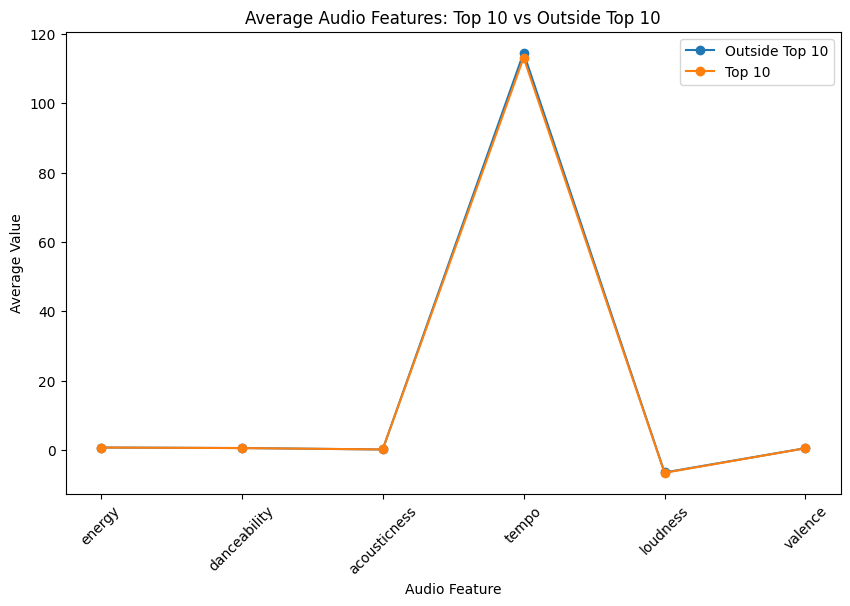

In [ ]:
plt.figure(figsize=(10, 6))

for group in top10_audio_long["song_group"].unique():
    subset = top10_audio_long[top10_audio_long["song_group"] == group]
    plt.plot(
        subset["audio_feature"],
        subset["average_value"],
        marker="o",
        label=group
    )

plt.title("Average Audio Features: Top 10 vs Outside Top 10")
plt.xlabel("Audio Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [ ]:
eurovision_audio_overview.to_csv(
    processed_path + "/eurovision_audio_overview.csv",
    index=False
)

winner_audio_comparison.to_csv(
    processed_path + "/winner_audio_comparison.csv",
    index=False
)

top10_audio_comparison.to_csv(
    processed_path + "/top10_audio_comparison.csv",
    index=False
)

top10_audio_long.to_csv(
    processed_path + "/top10_audio_long.csv",
    index=False
)

os.listdir(processed_path)

['sanremo_clean.csv',
 'eurovision_recent_clean.csv',
 'eurovision_voting_clean.csv',
 'eurovision_meta_clean.csv',
 'eurovision_voting_final_clean.csv',
 'sanremo_overview.csv',
 'sanremo_entries_by_decade.csv',
 'top_sanremo_artists.csv',
 'sanremo_winners_by_artist.csv',
 'top_sanremo_authors.csv',
 'sanremo_authors_exploded.csv',
 'top_sanremo_individual_authors.csv',
 'eurovision_recent_overview.csv',
 'eurovision_country_performance.csv',
 'top_eurovision_countries_points.csv',
 'top_eurovision_countries_top10.csv',
 'eurovision_audio_overview.csv',
 'winner_audio_comparison.csv',
 'top10_audio_comparison.csv',
 'top10_audio_long.csv']

### Eurovision Voting Analysis

This section explores Eurovision voting patterns using historical voting data.  
The goal is to identify countries receiving the most points, countries giving the most points and general voting dynamics across years.

In [ ]:
eurovision_voting_overview = pd.DataFrame({
    "metric": [
        "total_votes",
        "unique_years",
        "min_year",
        "max_year",
        "unique_giving_countries",
        "unique_receiving_countries",
        "total_points"
    ],
    "value": [
        len(eurovision_voting_clean),
        eurovision_voting_clean["year"].nunique(),
        eurovision_voting_clean["year"].min(),
        eurovision_voting_clean["year"].max(),
        eurovision_voting_clean["from_country"].nunique(),
        eurovision_voting_clean["to_country"].nunique(),
        eurovision_voting_clean["points"].sum()
    ]
})

eurovision_voting_overview

,metric,value
0,total_votes,51827
1,unique_years,68
2,min_year,1957
3,max_year,2025
4,unique_giving_countries,54
5,unique_receiving_countries,56
6,total_points,159845


### Eurovision Voting Overview

The Eurovision voting dataset contains more than 51,000 voting records from 1957 to 2025.

The points received analysis shows which countries accumulated the highest number of points across the available voting history. Sweden, Ukraine, Norway, Israel and Italy appear among the strongest countries by cumulative received points.

This analysis should be interpreted carefully because Eurovision voting rules, number of participating countries and scoring systems changed over time.

In [ ]:
eurovision_points_received = (
    eurovision_voting_clean
    .groupby("to_country")
    .agg(
        total_points_received=("points", "sum"),
        avg_points_received=("points", "mean"),
        votes_received=("points", "count"),
        years_present=("year", "nunique")
    )
    .reset_index()
    .sort_values("total_points_received", ascending=False)
)

eurovision_points_received.head(20)

,to_country,total_points_received,avg_points_received,votes_received,years_present
49,Sweden,8804,4.926693,1787,63
53,Ukraine,5874,5.741935,1023,20
38,Norway,5721,3.326163,1720,62
25,Israel,5660,3.726136,1519,46
26,Italy,5383,5.261975,1023,48
21,Greece,5220,3.441002,1517,44
42,Russia,5197,4.660987,1115,23
18,France,5048,3.192916,1581,66
50,Switzerland,4860,3.648649,1332,62
54,United Kingdom,4705,2.935122,1603,67


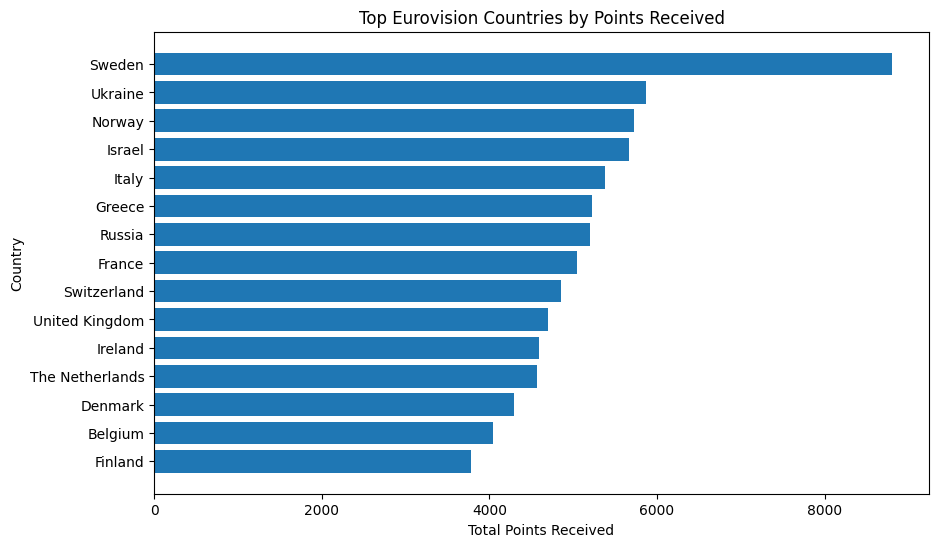

In [ ]:
top_points_received = eurovision_points_received.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_points_received["to_country"].iloc[::-1],
    top_points_received["total_points_received"].iloc[::-1]
)

plt.title("Top Eurovision Countries by Points Received")
plt.xlabel("Total Points Received")
plt.ylabel("Country")
plt.show()

In [ ]:
eurovision_points_given = (
    eurovision_voting_clean
    .groupby("from_country")
    .agg(
        total_points_given=("points", "sum"),
        avg_points_given=("points", "mean"),
        votes_given=("points", "count"),
        years_voting=("year", "nunique")
    )
    .reset_index()
    .sort_values("total_points_given", ascending=False)
)

eurovision_points_given.head(20)

,from_country,total_points_given,avg_points_given,votes_given,years_voting
52,United Kingdom,4416,2.712531,1628,62
46,Spain,4356,2.697214,1615,59
19,Germany,4346,2.716250,1600,62
36,Norway,4323,2.734345,1581,58
47,Sweden,4305,2.692308,1599,59
17,France,4298,2.686250,1600,61
23,Ireland,4234,2.715843,1559,53
7,Belgium,4228,2.711995,1559,60
49,The Netherlands,4196,2.722907,1541,59
48,Switzerland,4178,2.728935,1531,59


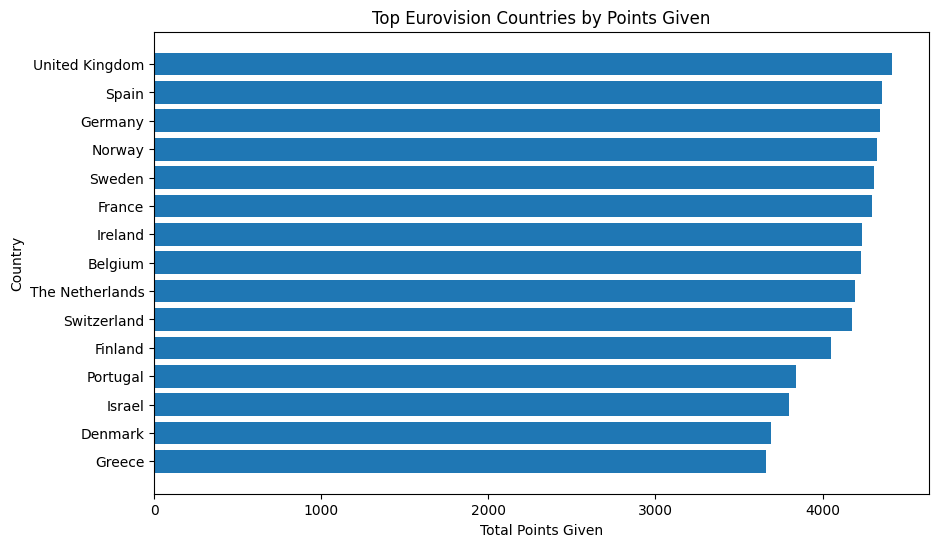

In [ ]:
top_points_given = eurovision_points_given.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_points_given["from_country"].iloc[::-1],
    top_points_given["total_points_given"].iloc[::-1]
)

plt.title("Top Eurovision Countries by Points Given")
plt.xlabel("Total Points Given")
plt.ylabel("Country")
plt.show()

In [ ]:
eurovision_points_by_year = (
    eurovision_voting_clean
    .groupby("year")
    .agg(
        total_points=("points", "sum"),
        total_votes=("points", "count"),
        avg_points=("points", "mean")
    )
    .reset_index()
    .sort_values("year")
)

eurovision_points_by_year.head()

,year,total_points,total_votes,avg_points
0,1957,100,43,2.325581
1,1958,100,44,2.272727
2,1959,110,55,2.000000
3,1960,130,64,2.031250
4,1961,160,79,2.025316


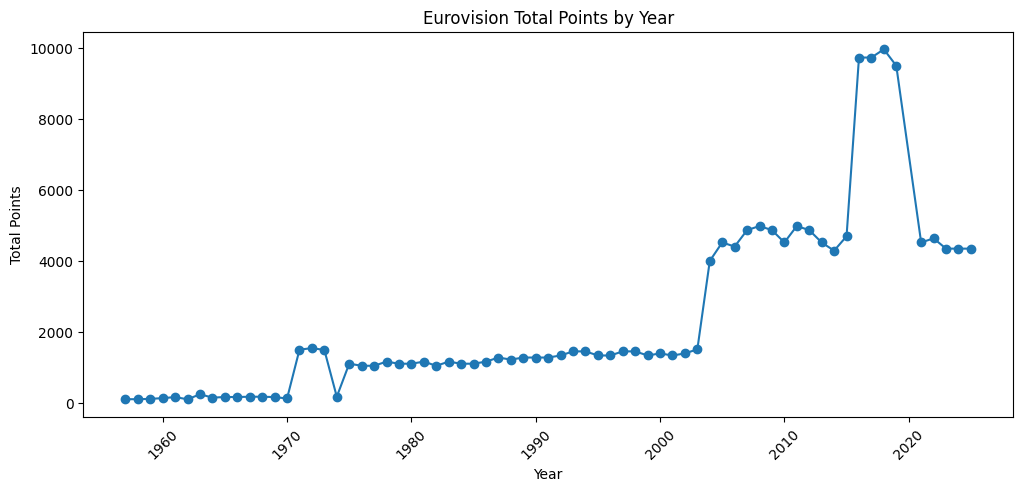

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(
    eurovision_points_by_year["year"],
    eurovision_points_by_year["total_points"],
    marker="o"
)

plt.title("Eurovision Total Points by Year")
plt.xlabel("Year")
plt.ylabel("Total Points")
plt.xticks(rotation=45)
plt.show()

In [ ]:
eurovision_voting_overview.to_csv(
    processed_path + "/eurovision_voting_overview.csv",
    index=False
)

eurovision_points_received.to_csv(
    processed_path + "/eurovision_points_received.csv",
    index=False
)

eurovision_points_given.to_csv(
    processed_path + "/eurovision_points_given.csv",
    index=False
)

eurovision_points_by_year.to_csv(
    processed_path + "/eurovision_points_by_year.csv",
    index=False
)

os.listdir(processed_path)

['sanremo_clean.csv',
 'eurovision_recent_clean.csv',
 'eurovision_voting_clean.csv',
 'eurovision_meta_clean.csv',
 'eurovision_voting_final_clean.csv',
 'sanremo_overview.csv',
 'sanremo_entries_by_decade.csv',
 'top_sanremo_artists.csv',
 'sanremo_winners_by_artist.csv',
 'top_sanremo_authors.csv',
 'sanremo_authors_exploded.csv',
 'top_sanremo_individual_authors.csv',
 'eurovision_recent_overview.csv',
 'eurovision_country_performance.csv',
 'top_eurovision_countries_points.csv',
 'top_eurovision_countries_top10.csv',
 'eurovision_audio_overview.csv',
 'winner_audio_comparison.csv',
 'top10_audio_comparison.csv',
 'top10_audio_long.csv',
 'eurovision_voting_overview.csv',
 'eurovision_points_received.csv',
 'eurovision_points_given.csv',
 'eurovision_points_by_year.csv']

### Eurovision Voting Insights

The voting analysis highlights which countries received and assigned the highest number of points across the available Eurovision voting dataset.

Countries with higher total points received are not necessarily always the best performers in a single year, but they show stronger cumulative performance across the historical voting period.

The yearly points trend should be interpreted carefully because Eurovision voting rules and the number of participating countries changed over time.

In [ ]:
eurovision_voting_overview.to_csv(
    processed_path + "/eurovision_voting_overview.csv",
    index=False
)

eurovision_points_received.to_csv(
    processed_path + "/eurovision_points_received.csv",
    index=False
)

eurovision_points_given.to_csv(
    processed_path + "/eurovision_points_given.csv",
    index=False
)

eurovision_points_by_year.to_csv(
    processed_path + "/eurovision_points_by_year.csv",
    index=False
)

os.listdir(processed_path)

['sanremo_clean.csv',
 'eurovision_recent_clean.csv',
 'eurovision_voting_clean.csv',
 'eurovision_meta_clean.csv',
 'eurovision_voting_final_clean.csv',
 'sanremo_overview.csv',
 'sanremo_entries_by_decade.csv',
 'top_sanremo_artists.csv',
 'sanremo_winners_by_artist.csv',
 'top_sanremo_authors.csv',
 'sanremo_authors_exploded.csv',
 'top_sanremo_individual_authors.csv',
 'eurovision_recent_overview.csv',
 'eurovision_country_performance.csv',
 'top_eurovision_countries_points.csv',
 'top_eurovision_countries_top10.csv',
 'eurovision_audio_overview.csv',
 'winner_audio_comparison.csv',
 'top10_audio_comparison.csv',
 'top10_audio_long.csv',
 'eurovision_voting_overview.csv',
 'eurovision_points_received.csv',
 'eurovision_points_given.csv',
 'eurovision_points_by_year.csv']

In [ ]:
processed_files = pd.DataFrame({
    "file_name": sorted(os.listdir(processed_path))
})

processed_files

,file_name
0,eurovision_audio_overview.csv
1,eurovision_country_performance.csv
2,eurovision_country_performance_tableau.csv
3,eurovision_meta_clean.csv
4,eurovision_points_by_year.csv
5,eurovision_points_given.csv
6,eurovision_points_received.csv
7,eurovision_recent_clean.csv
8,eurovision_recent_overview.csv
9,eurovision_voting_clean.csv


## Step 4 - Final Processed Outputs

The Sanremo and Eurovision datasets were cleaned, explored and transformed into analysis-ready CSV files.

The processed outputs include:
- Sanremo historical overview
- Sanremo entries by decade
- Top Sanremo artists by participations
- Top Sanremo artists by wins
- Top Sanremo individual authors
- Eurovision recent country performance
- Eurovision audio feature comparisons
- Eurovision voting trends and country-level voting summaries

These files will be used as input for the Tableau dashboard of the Festival Extension.

In [ ]:
# Create Tableau-ready Eurovision country performance file

eurovision_country_performance_tableau = eurovision_country_performance.copy()

numeric_columns = [
    "entries",
    "avg_final_place",
    "best_final_place",
    "total_final_points",
    "avg_final_points",
    "wins",
    "top_3_finishes",
    "top_10_finishes"
]

for col in numeric_columns:
    eurovision_country_performance_tableau[col] = pd.to_numeric(
        eurovision_country_performance_tableau[col],
        errors="coerce"
    )

# For cleaner Tableau import, remove unnecessary decimal .0 from integer-like columns
integer_columns = [
    "entries",
    "best_final_place",
    "total_final_points",
    "wins",
    "top_3_finishes",
    "top_10_finishes"
]

for col in integer_columns:
    eurovision_country_performance_tableau[col] = (
        eurovision_country_performance_tableau[col]
        .fillna(0)
        .astype(int)
    )

eurovision_country_performance_tableau.to_csv(
    processed_path + "/eurovision_country_performance_tableau.csv",
    index=False
)

eurovision_country_performance_tableau.head()

,country,entries,avg_final_place,best_final_place,total_final_points,avg_final_points,wins,top_3_finishes,top_10_finishes
44,Ukraine,8,8.14,1,2391,341.57,2,3,5
24,Italy,9,5.88,1,2648,331.00,1,2,7
23,Israel,9,12.29,1,1568,224.00,1,2,3
43,Switzerland,9,9.00,1,1557,311.40,1,2,3
42,Sweden,9,6.25,1,2517,314.62,1,1,7


In [ ]:
[file for file in os.listdir(processed_path) if "eurovision_country_performance" in file]

['eurovision_country_performance.csv',
 'eurovision_country_performance_tableau.csv']